In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress

In [2]:
def michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)

def linear_model(x, m):
    return m * x

In [3]:
data = pd.read_csv("data/kinetics_results.csv", sep=";")

In [4]:
proteins = data["Protein"].unique()  #["WT", "S166A", "Quad", "H191E", "H32L", "G37D", "K237R"]
substrate = data["SAM Conc"].unique()
timepoints = data["Timepoint"].unique()
replicates = data["Replicate"].unique()

index = pd.MultiIndex.from_product(
    [proteins, substrate, replicates],
    names=["Protein", "SAM Conc", "Replicate"]
)

# Convert to DataFrame
slopes = index.to_frame(index=False)

slopes["v0"] = 0
# slopes["v0_stderr"] = 0
# slopes["R2"] = 0

In [5]:
for prot in proteins:
    for S in substrate: 
        for rep in replicates:
            
            subset = data.loc[(data["Protein"]==prot) & (data["SAM Conc"]==S) & (data["Replicate"]==rep)]   ### Add to exclude values with >20% conversion: & (data["FDA used"]<20)
            
            t_data = np.array(subset["Timepoint"])
            P_data = np.array(subset["FDA Conc"]) 
            
            slope_opt, _ = curve_fit(linear_model, t_data, P_data)
            
            # slope, intercept, r_value, p_value, std_err = linregress(t_data, P_data)
            # print(slope_opt)
            
            slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "v0"] = slope_opt[0]
            # slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "v0_stderr"] = std_err
            # slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "R2"] = r_value

C:\Users\dhard\AppData\Local\Temp\ipykernel_7884\3066319733.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0680612752404093' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "v0"] = slope_opt[0]


In [6]:
index = pd.MultiIndex.from_product(
    [proteins, replicates],
    names=["Protein", "Replicate"]
)

# Convert to DataFrame
kindata = index.to_frame(index=False)

kindata["Vmax"] = 0
kindata["Enzyme_conc_mean"] = [0.967855038, 0.979340973, 0.978944906, 0.965214593, 0.973399972, 0.993071286, 0.997163975, 1.002576887, 0.994919597, 0.956369103, 0.975248283, 0.994391508, 0.979737039, 0.971683683, 0.994787575, 0.978416817, 0.988714552, 0.97802075, 0.977624684, 0.974060083, 1.008517888]
kindata["Enzyme_conc_stdev"] = 0
kindata["kcat"] = 0 
kindata["Km"] = 0


In [ ]:
kindata_for_bri = kindata[['Protein','Replicate','Enzyme_conc_mean']]
kindata_for_bri

In [14]:
# Match the Enzyme concentrations to the correct protein and replicate in the "data" DataFrame
data_matched = pd.merge(data, kindata_for_bri, on=['Protein', 'Replicate'], how='left')
data_matched.to_csv("data/kinetics_for_Bri.csv", sep=";", index=False)

C:\Users\dhard\AppData\Local\Temp\ipykernel_7884\932179792.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.2645214858918432' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Vmax"]] = Vmax_fit
C:\Users\dhard\AppData\Local\Temp\ipykernel_7884\932179792.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '81.27716854797536' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Km"]] = Km_fit


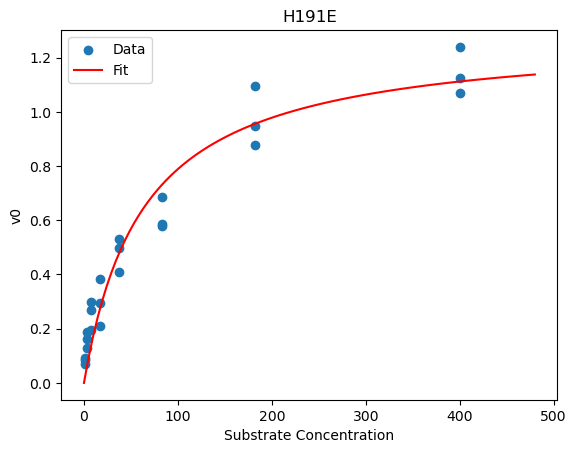

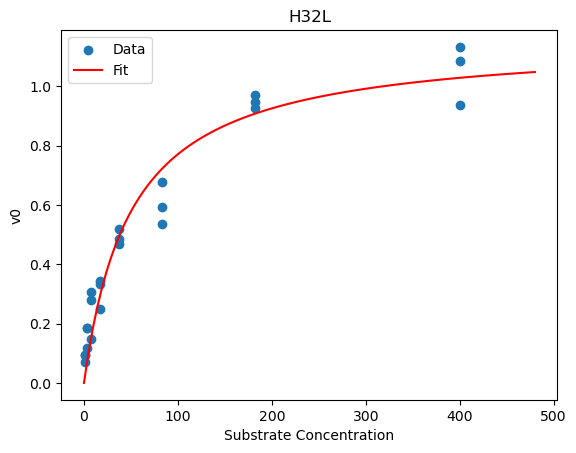

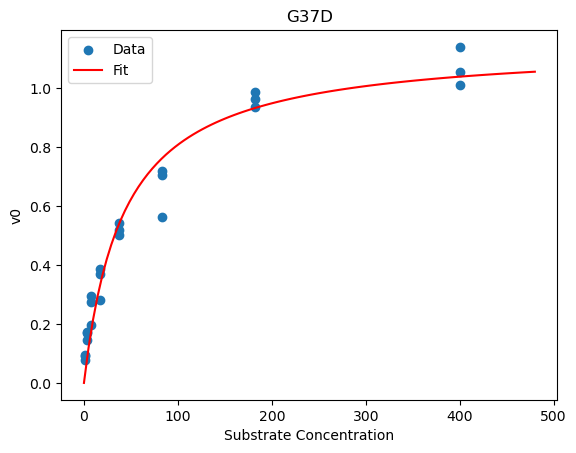

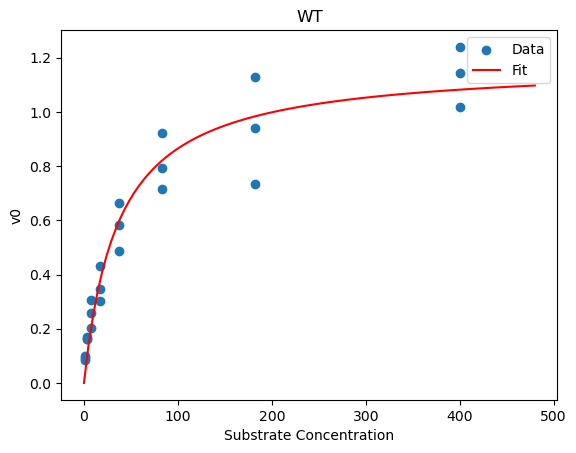

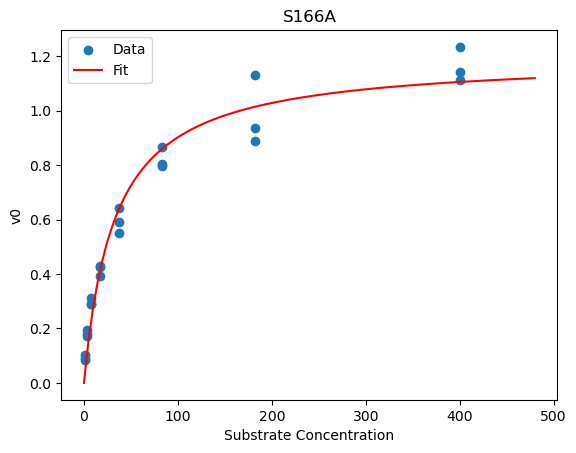

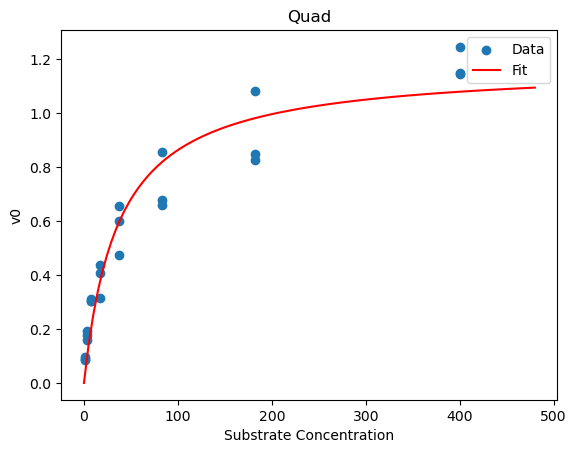

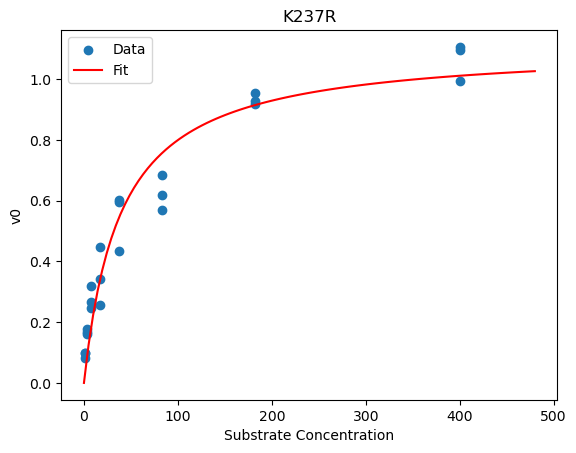

In [7]:
for prot in proteins: 
    for rep in replicates: 
            
        subset = slopes.loc[(slopes["Protein"]==prot) & (slopes["Replicate"]==rep)]
        
        S_data = np.array(subset["SAM Conc"])
        v_data = np.array(subset["v0"])
        
        popt, pcov = curve_fit(michaelis_menten, S_data, v_data, p0=[1.2, 30])
        Vmax_fit, Km_fit = popt
        
        
        kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Vmax"]] = Vmax_fit
        kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Km"]] = Km_fit
            
            
    subset = slopes.loc[(slopes["Protein"]==prot)]
    S_data = np.array(subset["SAM Conc"])
    v_data = np.array(subset["v0"])
    
    popt, pcov = curve_fit(michaelis_menten, S_data, v_data, p0=[1, 1])
    Vmax_fit, Km_fit = popt  

    S_fit = np.linspace(0, max(S_data)*1.2, 100)
    P_fit = michaelis_menten(S_fit, *popt)

    plt.scatter(S_data, v_data, label='Data')
    plt.plot(S_fit, P_fit, color='red', label='Fit')
    plt.title(prot)
    plt.xlabel('Substrate Concentration')
    plt.ylabel('v0')
    plt.legend()
    plt.show()


#kindata["kcat"] = kindata["Vmax"]/(kindata["Enzyme_conc_mean"]*6)          


In [24]:
kin_colors = {'WT': 'lightgrey',
    'Single': '#FFEFD3',
    'Target': '#516F84',
    'Combi': '#DF9966'}

variant_cat = {'WT':'WT',
    'S166A': 'Single',
                'Quad': 'Combi',
                'H191E': 'Single',
                'H32L': 'Single',
                'G37D': 'Single',
                'K237R': 'Target'}

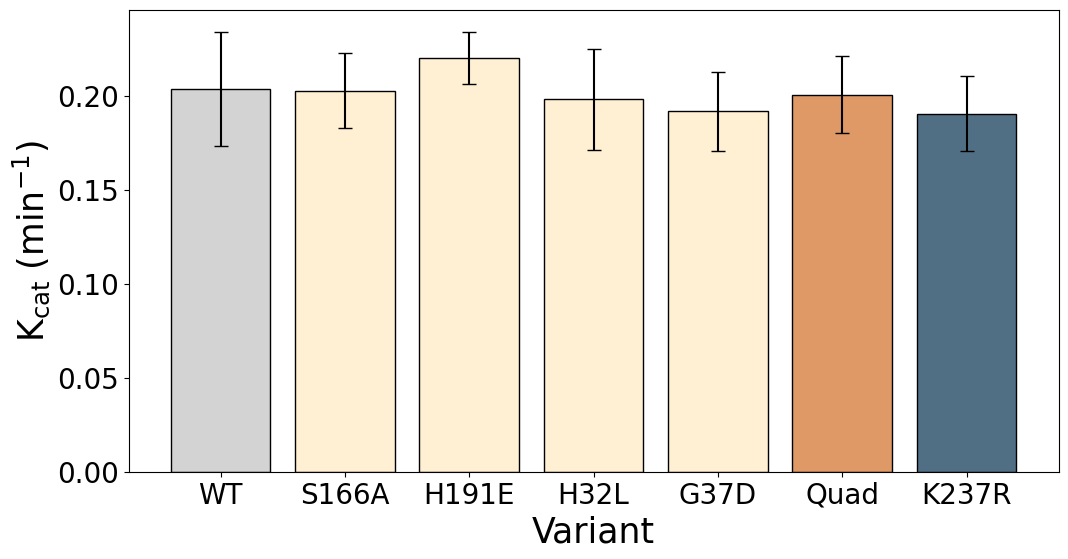

,Protein,mean,std
6,WT,0.203850,0.030378
5,S166A,0.202862,0.019902
1,H191E,0.220118,0.013940
2,H32L,0.198251,0.027011
0,G37D,0.191779,0.021172
4,Quad,0.200795,0.020669
3,K237R,0.190675,0.019895


In [25]:


# Example: Aggregating your data like in the Plotly version
kindata_kcat = kindata.groupby(by=["Protein"])["kcat"].agg(["mean", "std"]).reset_index()

# Order categories
order = ["WT", "S166A", "H191E", "H32L", "G37D", "Quad", "K237R"]
kindata_kcat["Protein"] = pd.Categorical(kindata_kcat["Protein"], categories=order, ordered=True)
kindata_kcat = kindata_kcat.sort_values("Protein")

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 6))
for prot in kindata_kcat['Protein']:
    cat = variant_cat[prot]
    ax.bar(
        prot, 
        kindata_kcat[kindata_kcat['Protein'] == prot]["mean"], 
        yerr=kindata_kcat[kindata_kcat['Protein'] == prot]["std"], 
        capsize=5,
        color=kin_colors[variant_cat[prot]],
        edgecolor="black", 
        linewidth=1.0
    )

# Labels
ax.set_xlabel("Mutants")
ax.set_ylabel("kcat")

# Styling background and axes
# ax.set_facecolor("white")
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_color('black')
# ax.spines['bottom'].set_color('black')

ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel('Variant', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{cat}$ (min$^{-1}$)', fontsize=25)

plt.show()

kindata_kcat.head(30)


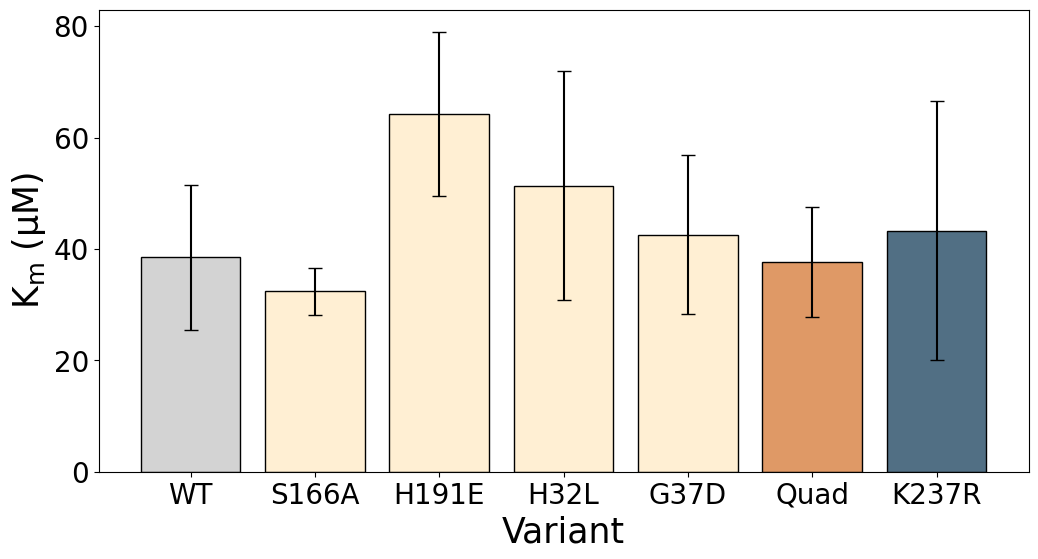

,Protein,mean,std
6,WT,38.491715,12.979276
5,S166A,32.372475,4.239113
1,H191E,64.288565,14.720214
2,H32L,51.323024,20.560755
0,G37D,42.554164,14.316174
4,Quad,37.663995,9.831706
3,K237R,43.286002,23.216156


In [26]:
# Example: Aggregating your data like in the Plotly version
kindata_km = kindata.groupby(by=["Protein"])["Km"].agg(["mean", "std"]).reset_index()

# Order categories
order = ["WT", "S166A", "H191E", "H32L", "G37D", "Quad", "K237R"]
kindata_km["Protein"] = pd.Categorical(kindata_km["Protein"], categories=order, ordered=True)
kindata_km = kindata_km.sort_values("Protein")

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 6))
for prot in kindata_km['Protein']:
    cat = variant_cat[prot]
    ax.bar(
        prot, 
        kindata_km[kindata_km['Protein'] == prot]["mean"], 
        yerr=kindata_km[kindata_km['Protein'] == prot]["std"], 
        capsize=5, 
        color=kin_colors[cat],
        edgecolor="black", 
        linewidth=1.0
    )

# Labels
ax.set_xlabel("Mutants")
ax.set_ylabel("Km")

# Styling background and axes
# ax.set_facecolor("white")
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_color('black')
# ax.spines['bottom'].set_color('black')

ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel('Variant', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{m}$ (μM)', fontsize=25)

plt.show()

kindata_km.head(30)


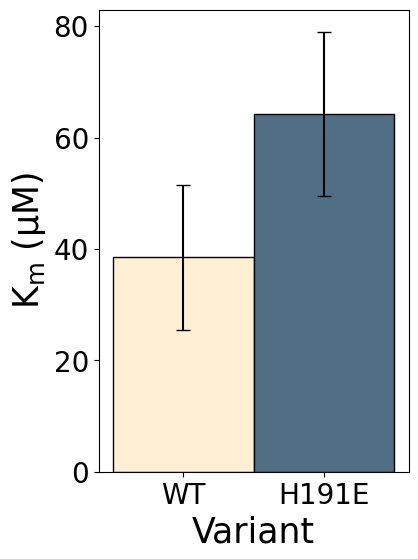

In [11]:
fig, ax = plt.subplots(figsize=(4, 6))
x = np.arange(2)
width = 1
subset_km = kindata_km[kindata_km["Protein"].isin(['WT','H191E'])]
ax.bar(
    subset_km["Protein"], 
    subset_km["mean"], 
    yerr=subset_km["std"], 
    width=width,
    capsize=5, 
    edgecolor="black", 
    linewidth=1.0,
    color=['#FFEFD3', '#516F84']
)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel('Variant', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{m}$ (µM)', fontsize=25)
plt.show()

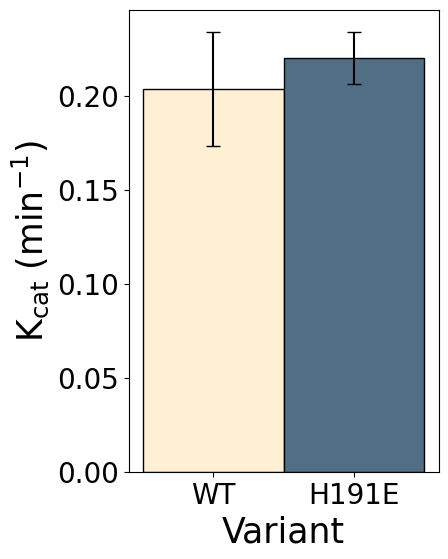

In [12]:
fig, ax = plt.subplots(figsize=(4, 6))
x = np.arange(2)
width = 1
subset_kcat = kindata_kcat[kindata_kcat["Protein"].isin(['WT','H191E'])]
ax.bar(
    subset_kcat["Protein"], 
    subset_kcat["mean"], 
    yerr=subset_kcat["std"], 
    width=width,
    capsize=5, 
    edgecolor="black", 
    linewidth=1.0,
    color=['#FFEFD3', '#516F84']
)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel('Variant', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{cat}$ (min$^{-1}$)', fontsize=25)
plt.show()

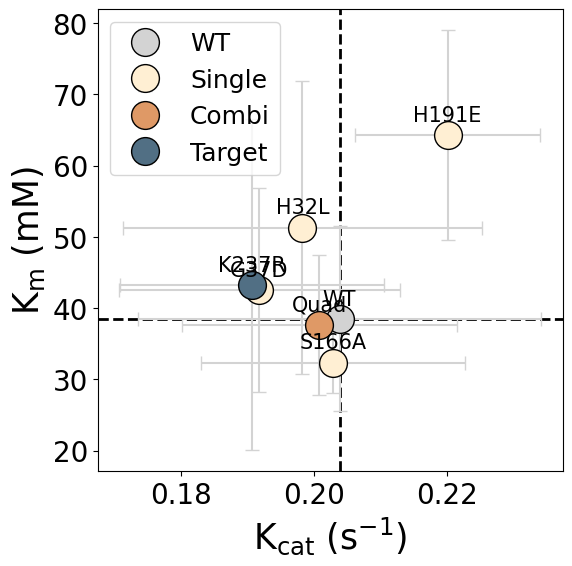

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.axvline(kindata_kcat['mean'].iloc[0], color='black', linewidth=2, linestyle='--',zorder=0)
ax.axhline(kindata_km['mean'].iloc[0], color='black', linewidth=2, linestyle='--',zorder=0)
#ax.scatter(exp_data_full['Kcat'].iloc[0], exp_data_full['Km'].iloc[0], s=200, color='lightgrey', edgecolor='black',zorder=2)
#ax.scatter(exp_data['Kcat'].iloc[0:7], exp_data['Km'].iloc[0:7], s=400, color=mutant_color['Single'], edgecolor='black',zorder=2,label='Rational, Single')
#ax.scatter(exp_data['Kcat'].iloc[7:9], exp_data['Km'].iloc[7:9], s=400, color=mutant_color['Double'], edgecolor='black',zorder=2,label='Rational, Double')
seen_cat = []
for prot in kindata_kcat['Protein']:
    cat = variant_cat[prot]
    ax.errorbar(
        kindata_kcat[kindata_kcat['Protein'] == prot]['mean'],
        kindata_km[kindata_km['Protein'] == prot]['mean'],
        xerr=kindata_kcat[kindata_kcat['Protein'] == prot]['std'],
        yerr=kindata_km[kindata_km['Protein'] == prot]['std'],
        fmt='o',
        color=kin_colors[variant_cat[prot]],
        ecolor='lightgrey',
        markeredgecolor='black',
        capsize=5,
        markersize=20,
        label=cat if cat not in seen_cat else None,
        zorder=2)
    seen_cat.append(cat)

    ax.annotate(
        prot,
        (kindata_kcat[kindata_kcat['Protein'] == prot]['mean'].values[0],
         kindata_km[kindata_km['Protein'] == prot]['mean'].values[0]),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=15,
        color='black'
    )
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel(r'K$_\mathrm{cat}$ (s$^{-1}$)', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{m}$ (mM)', fontsize=25)
ax.legend(fontsize=18, loc='upper left')
plt.savefig('FlA_Kinetics.svg', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
kindata_grouped = kindata.groupby(by=["Protein"])

In [15]:
kindata['kcat/Km'] = kindata['kcat']/ kindata['Km']

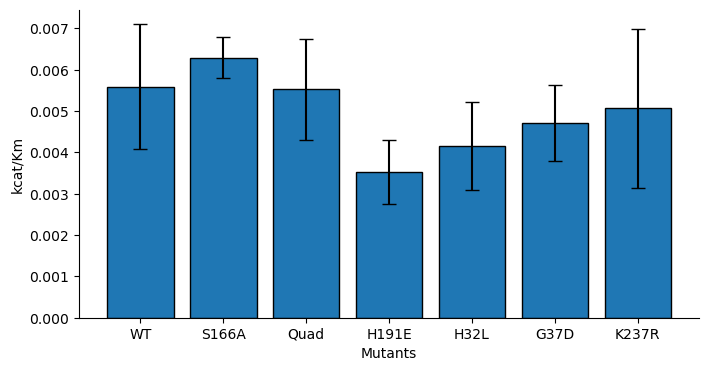

,Protein,mean,std
6,WT,38.491715,12.979276
5,S166A,32.372475,4.239113
1,H191E,64.288565,14.720214
2,H32L,51.323024,20.560755
0,G37D,42.554164,14.316174
4,Quad,37.663995,9.831706
3,K237R,43.286002,23.216156


In [16]:
# Example: Aggregating your data like in the Plotly version
kindata_cat_eff = kindata.groupby(by=["Protein"])['kcat/Km'].agg(["mean", "std"]).reset_index()

# Order categories
order = ["WT", "S166A", "Quad", "H191E", "H32L", "G37D", "K237R"]
kindata_cat_eff["Protein"] = pd.Categorical(kindata_cat_eff["Protein"], categories=order, ordered=True)
kindata_cat_eff = kindata_cat_eff.sort_values("Protein")

# Create bar plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    kindata_cat_eff["Protein"], 
    kindata_cat_eff["mean"], 
    yerr=kindata_cat_eff["std"], 
    capsize=5, 
    edgecolor="black", 
    linewidth=1.0
)

# Labels
ax.set_xlabel("Mutants")
ax.set_ylabel("kcat/Km")

# Styling background and axes
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.tick_params(axis='x', which='both', bottom=True, top=False, direction='out')
ax.tick_params(axis='y', which='both', left=True, right=False, direction='out')

plt.show()

kindata_km.head(30)